Task 1: GCP Environment and Billing Verification

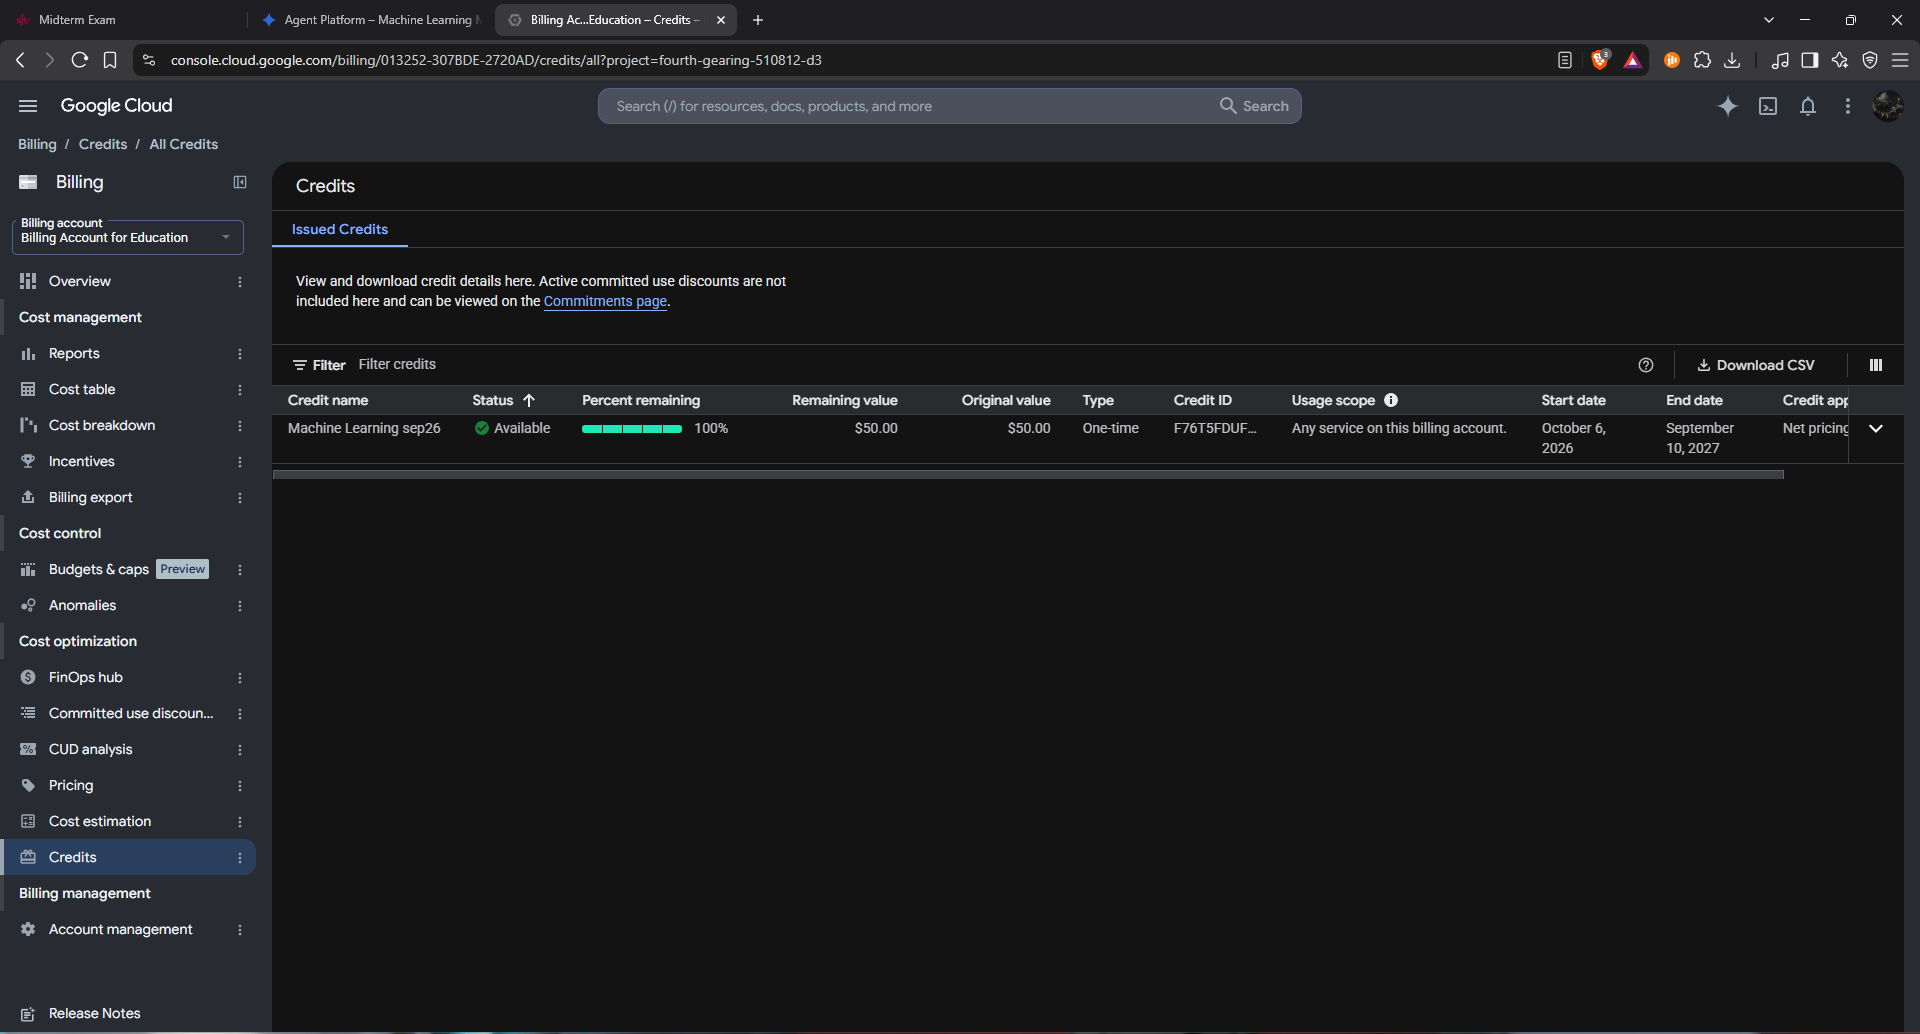

Task 2: Load UCI Air Quality Dataset

In [ ]:
import io
import urllib.request
import zipfile
import pandas as pd

# Download zip file directly into memory from UCI repository
url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

with urllib.request.urlopen(req) as response:
  with zipfile.ZipFile(io.BytesIO(response.read())) as zip_ref:
    zip_ref.extractall(".")

# Load dataset into pandas DataFrame
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",").dropna(how="all")

# Drop trailing empty columns often present in this raw CSV
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Task 3: Structural Inspection

In [ ]:
# Check data shape and column data types
print(f"Dataset Shape: {df.shape}\n")
df.info()

# Summary statistics across all numerical features
df.describe()

Dataset Shape: (9357, 15)

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


Task 4: Missing Value Handling and Imputation

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

# Replace -200 sentinel values with NaN
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace(-200, np.nan)

# Display missing counts
print("Missing values per column after replacing -200:")
print(df[num_cols].isna().sum())

# Demonstrate SimpleImputer without mutating df
demo_imputer = SimpleImputer(strategy='median')
demo_imputed = demo_imputer.fit_transform(df[num_cols])
print("\nDemonstration: Remaining missing values after imputation:", np.isnan(demo_imputed).sum())

Missing values per column after replacing -200:
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Demonstration: Remaining missing values after imputation: 0


Task 5: Preprocessing Pipeline and Column Transformer

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ["Date", "Time"]
numerical_cols = [col for col in df.columns if col not in categorical_cols]

# Chain imputer + scaler so the pipeline self-contains missing value handling
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

X_processed = preprocessor.fit_transform(df)
print(f"Processed feature matrix shape: {X_processed.shape}")

Processed feature matrix shape: (9357, 428)


Task 6: Continuous Regression and Regularization

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# 1. Prepare target and filter out unobserved target entries
target_col = "CO(GT)"
df_clf = df.dropna(subset=[target_col]).copy()

# Target Binning: 3 quantiles (0: Low, 1: Moderate, 2: High)
y = pd.qcut(df_clf[target_col], q=3, labels=[0, 1, 2])
X = df_clf.drop(columns=[target_col])

# Feature columns
cat_cols = ["Date", "Time"]
num_cols = [c for c in X.columns if c not in cat_cols]

# Build preprocessor containing imputer + scaler to prevent data leakage
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

clf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Transform features (fitted strictly on X_train)
X_train_proc = clf_preprocessor.fit_transform(X_train)
X_test_proc = clf_preprocessor.transform(X_test)

# 2. Train Softmax / Multinomial Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_proc, y_train)
y_pred_log = log_reg.predict(X_test_proc)

print("=== Logistic / Softmax Regression Report ===")
print(classification_report(y_test, y_pred_log))

# 3. Train SGDClassifier (loss="log_loss" for probability calibration)
sgd_clf = SGDClassifier(
    loss="log_loss", penalty="l2", alpha=0.001, max_iter=1000, random_state=42
)
sgd_clf.fit(X_train_proc, y_train)
y_pred_sgd = sgd_clf.predict(X_test_proc)

print("=== SGDClassifier Report ===")
print(classification_report(y_test, y_pred_sgd))

=== Logistic / Softmax Regression Report ===
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       525
           1       0.85      0.85      0.85       501
           2       0.94      0.92      0.93       509

    accuracy                           0.90      1535
   macro avg       0.90      0.90      0.90      1535
weighted avg       0.90      0.90      0.90      1535

=== SGDClassifier Report ===
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       525
           1       0.85      0.82      0.83       501
           2       0.91      0.93      0.92       509

    accuracy                           0.89      1535
   macro avg       0.89      0.89      0.89      1535
weighted avg       0.89      0.89      0.89      1535



Task 7:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Setup continuous target and drop rows where the target is missing
reg_target = "C6H6(GT)"
df_reg = df.dropna(subset=[reg_target]).copy()

y_reg = df_reg[reg_target]
X_reg = df_reg.drop(columns=[reg_target])

cat_cols = ["Date", "Time"]
num_cols = [c for c in X_reg.columns if c not in cat_cols]

# Build preprocessing sub-pipelines (imputer + scaler prevents leakage)
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

# Train-test split
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Fit strictly on train, transform test
X_tr_proc = reg_preprocessor.fit_transform(X_tr_reg)
X_te_proc = reg_preprocessor.transform(X_te_reg)

# 2. Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_tr_proc, y_tr_reg)
y_pred_lr = lr.predict(X_te_proc)
print(
    f"Linear Regression -> R2: {r2_score(y_te_reg, y_pred_lr):.4f}, RMSE: {np.sqrt(mean_squared_error(y_te_reg, y_pred_lr)):.4f}"
)

# 3. Ridge Regression (L2) with varying alpha
for a in [0.1, 1.0, 10.0]:
    ridge = Ridge(alpha=a, random_state=42)
    ridge.fit(X_tr_proc, y_tr_reg)
    y_pred_ridge = ridge.predict(X_te_proc)
    print(
        f"Ridge (alpha={a}) -> R2: {r2_score(y_te_reg, y_pred_ridge):.4f}, RMSE: {np.sqrt(mean_squared_error(y_te_reg, y_pred_ridge)):.4f}"
    )

# 4. Lasso Regression (L1) with feature sparsity inspection
for a in [0.01, 0.1, 1.0]:
    lasso = Lasso(alpha=a, random_state=42, max_iter=2000)
    lasso.fit(X_tr_proc, y_tr_reg)
    y_pred_lasso = lasso.predict(X_te_proc)
    zero_coefs = np.sum(lasso.coef_ == 0)
    print(
        f"Lasso (alpha={a}) -> R2: {r2_score(y_te_reg, y_pred_lasso):.4f}, Zero Coefs: {zero_coefs}/{len(lasso.coef_)}"
    )

Linear Regression -> R2: 0.9913, RMSE: 0.7087
Ridge (alpha=0.1) -> R2: 0.9912, RMSE: 0.7123
Ridge (alpha=1.0) -> R2: 0.9902, RMSE: 0.7505
Ridge (alpha=10.0) -> R2: 0.9865, RMSE: 0.8797
Lasso (alpha=0.01) -> R2: 0.9790, Zero Coefs: 398/419
Lasso (alpha=0.1) -> R2: 0.9728, Zero Coefs: 411/419
Lasso (alpha=1.0) -> R2: 0.9451, Zero Coefs: 417/419


Task 8:

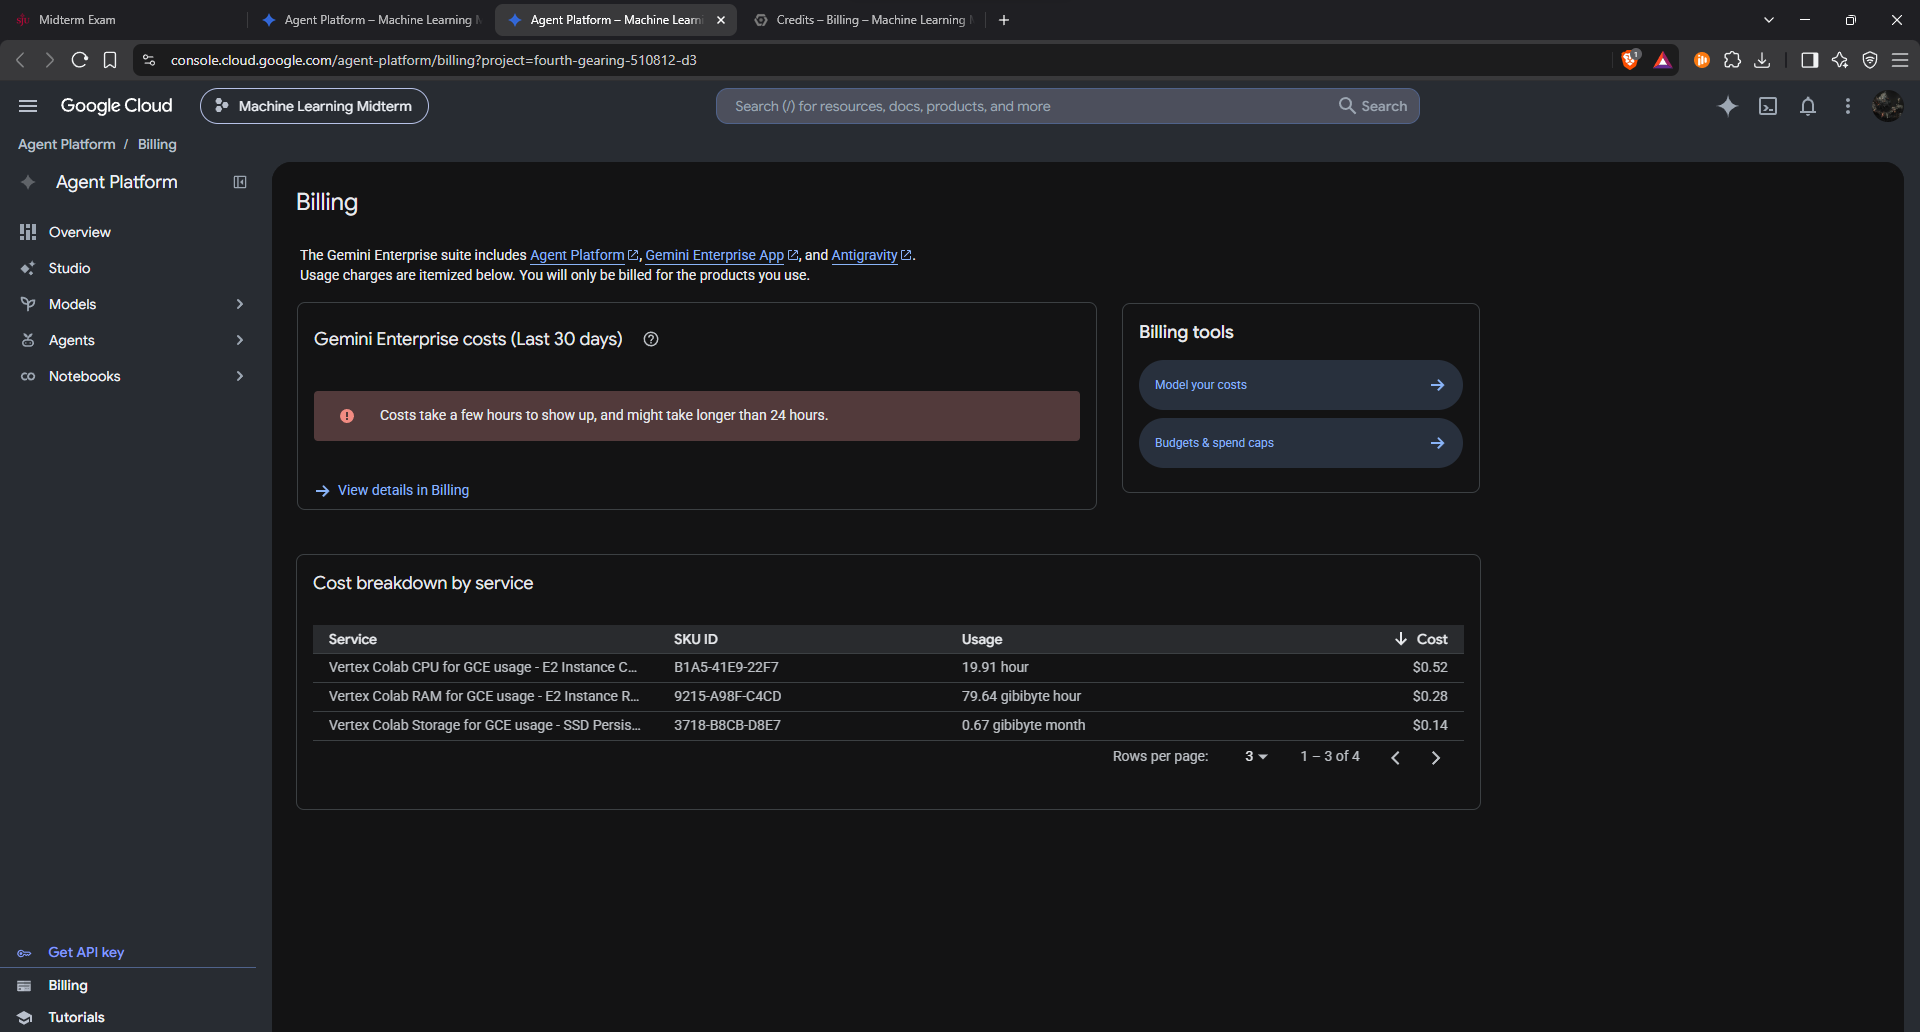